<h1 align="center">Quantiles extrêmes</h1>

Le but de ce notebook est de mettre en pratique les deux premières séances du cours sur la théorie des quantiles extrêmes. Nous allons donc nous intéresser dans un premier temps à une distribution unidimensionnelle pour l'instant. Fidèle à l'exemple évoqué en cours, nous allons appliquer ces résultats à l'historique de l'élévation du niveau de la *Seine*. Plus particulièrement, nous allons identifier le **domaine d'attraction** de cette distribution (*Fréchet*, *Weibull* ou *Gumbel*), estimer les **paramètres de la distribution limite**, et enfin estimer les **quantiles extrêmes** de cette distribution.

L'ajout de la notion de dépendance dans un modèle multidimensionnel est plus délicat, et nous y reviendrons dans un second temps, avec l'utilisation des **copules** dans un autre jupyter notebook.

# Récupération des données

Commençons par récupérer les données. 

Les données sont disponibles sur le site [EAUFRANCE](https://hydro.eaufrance.fr/stationhydro/F700000102/fiche) - contenant les mesures de la hauteur de la Seine sous le Pont d'Austerlitz de manière quotidienne depuis le 26 septembre 1885.

Le fichier `provenance_donnees.md` permet de tracher chaque fichier de données utilisés pour ce projet.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import seaborn as sns

In [2]:
seine_av1966 = pd.read_csv("data/EAUFRANCE-F700000109-Seine_Paris_Austerlitz-historique_av_1966.csv", sep=",")
seine_1966_1973 = pd.read_csv("data/EAUFRANCE-F700000110-Seine_Paris_Austerlitz-historique_1966-1973.csv", sep=",")
seine_1974_1989 = pd.read_csv("data/EAUFRANCE-F700000111-Seine_Paris_Austerlitz-historique_1974-1989.csv", sep=",")
seine_1990_2026 = pd.read_csv("data/EAUFRANCE-F700000102-Seine_Paris_Austerlitz-limini-1990-2026.csv", sep=",")

In [3]:
# Concaténation des DataFrames
seine = pd.concat([seine_av1966, seine_1966_1973, seine_1974_1989, seine_1990_2026], ignore_index=True)
seine.head()

,Date (TU),Date de la mesure du min/max (TU),Valeur (en m),Statut,Qualification,Méthode,Continuité
0,1885-09-26T00:00:00.000Z,1885-09-26T08:00:00.000Z,0.90,12,20,10,1
1,1885-09-27T00:00:00.000Z,1885-09-27T23:59:59.000Z,0.75,12,20,10,0
2,1885-09-28T00:00:00.000Z,1885-09-28T15:00:00.000Z,0.90,12,20,10,0
3,1885-09-29T00:00:00.000Z,1885-09-29T08:00:00.000Z,0.90,12,20,10,0
4,1885-09-30T00:00:00.000Z,1885-09-30T08:00:00.000Z,0.90,12,20,10,0


In [4]:
# Transform the 'Date' column which is YYYY-MM-DDT00:00:00.000Z to datetime format
seine['Date (TU)'] = pd.to_datetime(seine['Date (TU)'], format='%Y-%m-%dT%H:%M:%S.%fZ')
seine.drop(columns=['Date de la mesure du min/max (TU)', 'Statut', 'Qualification', 'Méthode', 'Continuité'], inplace=True)
# Rename the 'Valeur (en m)' column to 'Hauteur'
seine.rename(columns={'Valeur (en m)': 'Hauteur'}, inplace=True)
seine.rename(columns={'Date (TU)': 'Date'}, inplace=True)
seine.head() 

,Date,Hauteur
0,1885-09-26,0.90
1,1885-09-27,0.75
2,1885-09-28,0.90
3,1885-09-29,0.90
4,1885-09-30,0.90


In [5]:
seine.describe() 

,Date,Hauteur
count,50926,50926.000000
mean,1956-04-11 10:36:31.697758,1.456349
min,1885-09-26 00:00:00,-1.250000
25%,1921-06-27 06:00:00,1.000000
50%,1956-05-05 12:00:00,1.150000
75%,1991-03-20 18:00:00,1.600000
max,2026-03-25 00:00:00,8.620000
std,NaN,0.794490


In [6]:
# count nan values in the 'Hauteur' column
print(seine['Hauteur'].isna().sum())

0


Nous avons plus de 130 ans de données, grâce à EAUFRANCE, ce qui nous permettra d'avoir une bonne estimation de la distribution des quantiles extrêmes.

Les données ont déjà été nettoyées et préparées. 

# Première analyse des données

In [7]:
mean, std = seine["Hauteur"].mean(), seine["Hauteur"].std()
print(f"Mean: {mean:.2f}, Std: {std:.2f}")

Mean: 1.46, Std: 0.79


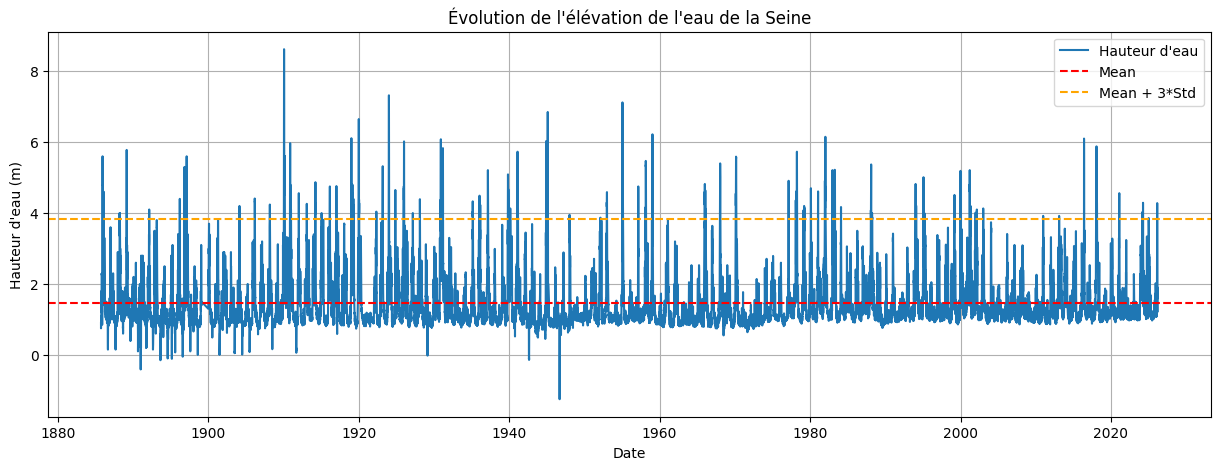

In [8]:
# Now draw a plot of the elevation of the water over time
plt.figure(figsize=(15, 5))
plt.plot(seine["Date"], seine["Hauteur"], label="Hauteur d'eau")
# Plot the mean and the mean + 3*std
plt.axhline(mean, color="red", linestyle="--", label="Mean")
plt.axhline(mean + 3 * std, color="orange", linestyle="--", label="Mean + 3*Std")
plt.legend()
plt.xlabel("Date")
plt.ylabel("Hauteur d'eau (m)")
plt.title("Évolution de l'élévation de l'eau de la Seine")
plt.grid()
plt.show()

La courbe dépasse de beaucoup la barre des $+3\sigma$, ce qui suggère que la distribution n'est pas gaussienne et possède une queue lourde. Nous allons vérifier cela dans la section suivante.

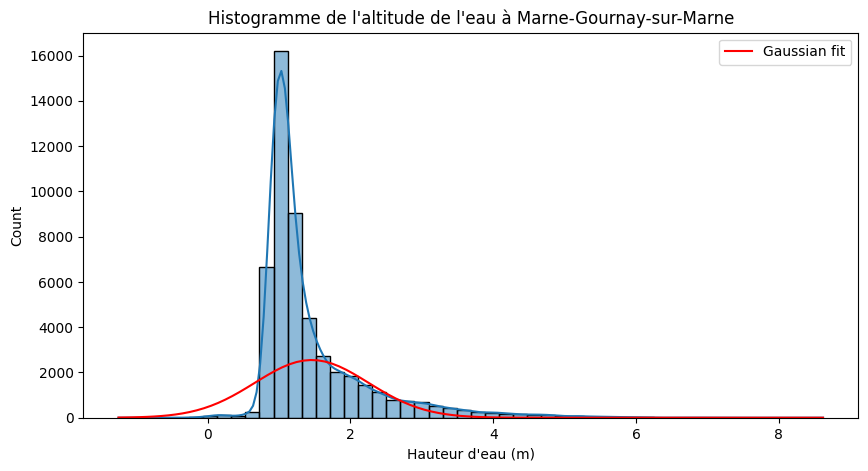

In [9]:
# Draw a histogram of the elevation of the water
plt.figure(figsize=(10, 5))
# Plot de l'histogramme de l'altitude de l'eau avec une courbe de densité
sns.histplot(seine["Hauteur"], bins=50, kde=True)
# Plot d'une gaussienne avec la même moyenne et écart-type que les données
x = np.linspace(seine["Hauteur"].min(), seine["Hauteur"].max(), 100)
plt.plot(x, stats.norm.pdf(x, mean, std) * len(seine["Hauteur"]) * (x[1] - x[0]), color="red", label="Gaussian fit")
plt.legend()
plt.xlabel("Hauteur d'eau (m)")
plt.title("Histogramme de l'altitude de l'eau à Marne-Gournay-sur-Marne")
plt.show()

On voit bien avec des deux figures que la distribution n'est pas gaussienne et possède une queue lourde. Elle appartiendrait donc au domaine d'attraction de Fréchet. Nous allons vérifier cela dans la section suivante.

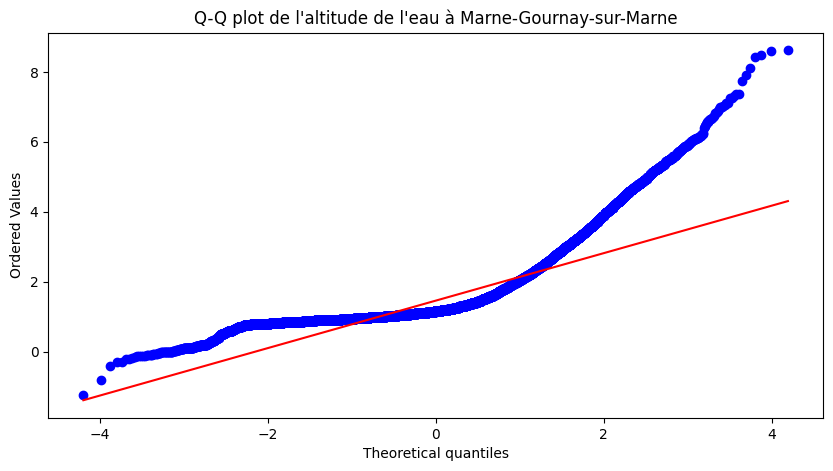

In [10]:
# Normale Q-Q plot
plt.figure(figsize=(10, 5))
stats.probplot(seine["Hauteur"], dist="norm", plot=plt)
plt.title("Q-Q plot de l'altitude de l'eau à Marne-Gournay-sur-Marne")
plt.show()

Là aussi le Q-Q plot montre que la distribution n'est pas gaussienne, et que les données ont une queue lourde à droite. Nous allons vérifier cela dans la section suivante.

## Rappel — Lire un Q-Q plot (Quantile-Quantile)

Un **Q-Q plot** compare les quantiles observés de vos données (axe vertical) aux quantiles théoriques d’une loi de référence (axe horizontal, souvent normale ou GEV).

### Comment le lire rapidement

- **Points proches d’une droite** : la loi de référence décrit bien les données.
- **Décalage global (droite non centrée)** : différence de position (moyenne / localisation).
- **Pente différente de 1** : différence d’échelle (écart-type / dispersion).
- **Courbure en S** : asymétrie ou mauvaise forme globale de la distribution.
- **Écarts marqués aux extrémités** : problème d’ajustement dans les queues (extrêmes), point crucial en EVT.

### Interprétation des queues

- **Extrémité droite au-dessus de la droite** : queue droite plus lourde que le modèle.
- **Extrémité droite en dessous** : queue droite plus légère que le modèle.
- Même logique à gauche pour la queue gauche.

### Dans ce notebook (maxima annuels + GEV)

- Si les points restent proches de la droite, l’ajustement GEV est cohérent.
- Les écarts en haut à droite indiquent une possible sous/surestimation des **quantiles extrêmes** (périodes de retour élevées).
- Un Q-Q plot aide au diagnostic visuel, mais doit être complété par des critères quantitatifs (AIC/BIC, IC des paramètres, tests de stabilité).

# Estimation des paramètres de la distribution limite

Effectuons un fit des données à une distribution de GEV (Generalized Extreme Value) pour estimer les paramètres de la distribution limite des maxima. Pour cela, nous allons utiliser la méthode `fit` de `scipy.stats.genextreme`.

On rassemble les données par maximum mensuel. 

In [11]:
# Calcul du maximum annuel pour l'analyse des extrêmes par année
annual_max = seine.groupby(seine["Date"].dt.to_period("Y"))["Hauteur"].max()
monthly_max = seine.groupby(seine["Date"].dt.to_period("M"))["Hauteur"].max()

### Comment fonctionne mathématiquement `scipy.stats.genextreme.fit`




Dans `scipy.stats`, la loi `genextreme` (GEV) est paramétrée par un triplet $(c, \mu, \sigma)$ avec :



- $c$ : **paramètre de forme** (shape) — attention, en théorie des valeurs extrêmes on note souvent $\xi = -c$,

- $\mu \in \mathbb{R}$ : **paramètre de position** (location),

- $\sigma > 0$ : **paramètre d'échelle** (scale).



#### 1. Rappel : forme de la loi GEV



Pour $x$ tel que $1 + c\,z > 0$ avec $z = \dfrac{x - \mu}{\sigma}$, la fonction de répartition (CDF) de la GEV s’écrit :

$$

F(x; c, \mu, \sigma) = \exp\Big( -\big(1 + c\,z\big)^{-1/c} \Big),

$$



et la densité (PDF) correspondante est :

$$

f(x; c, \mu, \sigma) = \frac{1}{\sigma}\, \big(1 + c\,z\big)^{-1/c - 1} \exp\Big( -\big(1 + c\,z\big)^{-1/c} \Big),

$$

valable pour $1 + c\,z > 0$ et nulle sinon.



Lien avec la notation classique en EVT :

- on pose $\xi = -c$,

- $\xi>0$ : domaine de Fréchet (queue lourde),

- $\xi<0$ : domaine de Weibull (support supérieur borné),

- $\xi=0$ (limite $c \to 0$) : loi de Gumbel.



#### 2. Données et hypothèse de modèle



On dispose de données $x_1,\dots,x_n$ supposées i.i.d. suivant une loi GEV :

$$

X_i \sim \text{GEV}(c,\mu,\sigma), \quad i=1,\dots,n.

$$

En pratique, ce sont des **maxima de blocs** (annuels, mensuels, etc.), ce qui justifie l’utilisation de la GEV comme loi limite.



L’objectif de `genextreme.fit` est de trouver des estimations $(\hat c, \hat \mu, \hat \sigma)$ de $(c,\mu,\sigma)$ à partir de $x_1,\dots,x_n$.



#### 3. Fonction de vraisemblance



Sous l’hypothèse i.i.d., la **vraisemblance** est le produit des densités :

$$

L(c,\mu,\sigma; x_1,\dots,x_n) = \prod_{i=1}^n f(x_i; c,\mu,\sigma),

$$

avec $f$ la densité GEV ci-dessus. En pratique on travaille avec le **logarithme de la vraisemblance** :

$$

\ell(c,\mu,\sigma) = \log L(c,\mu,\sigma) = \sum_{i=1}^n \log f(x_i; c,\mu,\sigma).

$$

En insérant l’expression de $f$, on obtient (pour tous les $i$ tels que $1+c z_i>0$, où $z_i = (x_i - \mu)/\sigma$) :

$$

\ell(c,\mu,\sigma) = -n\log\sigma -\Big(1 + \frac{1}{c}\Big)\sum_{i=1}^n \log(1 + c z_i) - \sum_{i=1}^n (1 + c z_i)^{-1/c}.

$$

Si pour un triplet $(c,\mu,\sigma)$ donné il existe un indice $i$ tel que $1 + c z_i \le 0$, alors la vraisemblance est définie comme **nulle** (log-vraisemblance $= -\infty$).



#### 4. Principe de `fit` : maximum de vraisemblance numérique



`scipy.stats.genextreme.fit` renvoie des estimateurs du **maximum de vraisemblance** (EMV) :

$$

(\hat c, \hat \mu, \hat \sigma) = \arg\max_{c,\mu,\sigma} \; \ell(c,\mu,\sigma),

$$

sous les contraintes :

- $\sigma>0$,

- $1 + c (x_i - \mu)/\sigma > 0$ pour tout $i$.



Il n’existe pas de forme fermée simple des équations du maximum de vraisemblance (les dérivées partielles $\partial \ell / \partial c$, $\partial \ell / \partial \mu$, $\partial \ell / \partial \sigma$ ne se résolvent pas analytiquement). `scipy` utilise donc une **optimisation numérique** (méthode de type quasi-Newton / gradient, via les routines d’optimisation de `scipy.optimize`) :



1. Choix de valeurs initiales raisonnables (par exemple $\mu$ proche de la moyenne, $\sigma$ proche de l’écart-type, $c$ proche de 0).

2. Évaluation répétée de la log-vraisemblance $\ell(c,\mu,\sigma)$ et éventuellement de son gradient numérique.

3. Mise à jour itérative du triplet $(c,\mu,\sigma)$ jusqu’à convergence vers un maximum local (critère de tolérance sur la variation de $\ell$ ou des paramètres).



La fonction renvoie alors $(\hat c, \hat \mu, \hat \sigma)$. Dans le cadre de l’EVT, on convertit généralement $\hat c$ en $\hat \xi = -\hat c$.



#### 5. Interprétation des paramètres estimés



À partir des estimateurs :



- $\hat c$ (ou $\hat \xi = -\hat c$) quantifie la **queue** de la distribution :

  - $\hat \xi > 0$ : queue lourde (Fréchet),

  - $\hat \xi < 0$ : queue bornée (Weibull),

  - $\hat \xi \approx 0$ : comportement type Gumbel.

- $\hat \mu$ décrit une position typique des maxima de bloc.

- $\hat \sigma$ décrit la dispersion des maxima autour de $\hat \mu$.



Enfin, une fois le triplet estimé, on peut calculer rigoureusement les **quantiles de période de retour** $T$ via l’inverse de la CDF GEV :

$$

q_T = F^{-1}\big(1 - 1/T; \hat c, \hat \mu, \hat \sigma\big),

$$

ce qui correspond au niveau qui a une probabilité annuelle $1/T$ d’être dépassé (sous l’hypothèse que les blocs correspondent chacun à une année et que les maxima annuels sont i.i.d.).


## Fit sur les maxima annuels

In [12]:
# Fit GEV avec scipy: genextreme utilise la convention c = -xi
params_fit_annual = stats.genextreme.fit(annual_max.values)
c, mu, sigma = params_fit_annual
xi = -c

print("Paramètres estimés de la loi limite (GEV):")
print(f"  xi (shape)   = {xi:.4f}")
print(f"  mu (location)= {mu:.4f}")
print(f"  sigma (scale)= {sigma:.4f}")

Paramètres estimés de la loi limite (GEV):
  xi (shape)   = -0.1185
  mu (location)= 3.4309
  sigma (scale)= 1.1820


Le paramètre $\xi$ est négatif, ce qui suggère que la distribution limite appartient au domaine d'attraction de Gumbel. 

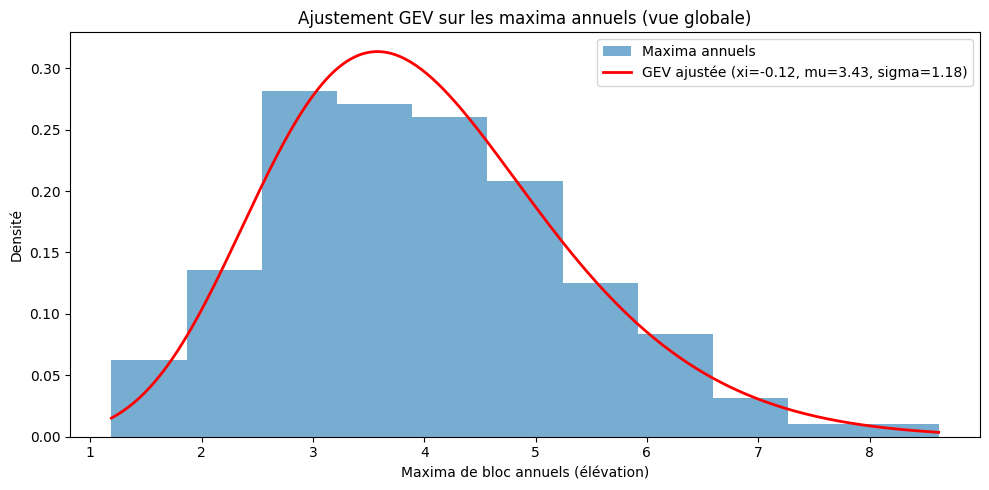

In [13]:
# Diagnostic visuel simple: histogramme des maxima annuels + densité GEV ajustée
x = np.linspace(annual_max.min(), annual_max.max(), 300)
gev_pdf = stats.genextreme.pdf(x, c, loc=mu, scale=sigma)

plt.figure(figsize=(10, 5))

plt.hist(annual_max, bins="auto", density=True, alpha=0.6, label="Maxima annuels")
plt.plot(x, gev_pdf, "r-", lw=2, label=f"GEV ajustée (xi={xi:.2f}, mu={mu:.2f}, sigma={sigma:.2f})")
plt.xlabel("Maxima de bloc annuels (élévation)")
plt.ylabel("Densité")
plt.title("Ajustement GEV sur les maxima annuels (vue globale)")
plt.legend()

plt.tight_layout()
plt.show()



# Estimation des quantiles extrêmes

Ce qui nous permet d'estimer les quantiles extrêmes de la distribution limite, et ainsi d'estimer les niveaux d'élévation correspondant à des périodes de retour de 10 ans, 100 ans, etc.

In [14]:
c, mu, sigma = params_fit_annual
xi = -c
print(f"Paramètres GEV ajustée (max annuels): xi={xi:.4f}, mu={mu:.4f}, sigma={sigma:.4f}")

Paramètres GEV ajustée (max annuels): xi=-0.1185, mu=3.4309, sigma=1.1820


In [15]:
# Estimation des quantiles extrêmes
alphas = [0.1, 0.01, 0.001, 0.0001]  # Probabilité de dépassement pour les périodes de retour
quantiles = stats.genextreme.ppf(1-np.array(alphas), c, loc=mu, scale=sigma)
print("Quantiles extrêmes estimés pour différents périodes de retour:")
for alpha, q in zip(alphas, quantiles):
    print(f"Quantile pour P(X > x) = {1-alpha:.4f}: {q:.2f} m")

Quantiles extrêmes estimés pour différents périodes de retour:
Quantile pour P(X > x) = 0.9000: 5.77 m
Quantile pour P(X > x) = 0.9900: 7.62 m
Quantile pour P(X > x) = 0.9990: 9.01 m
Quantile pour P(X > x) = 0.9999: 10.06 m


In [16]:
# Estimation des quantiles extrêmes - a du sens si on regroupe par months
return_periods = np.array([10, 50, 100, 200, 500, 1000,2000, 5000, 10000]) # Périodes de retour en années
quantiles = stats.genextreme.ppf(1 - 1/return_periods, c, loc=mu, scale=sigma)
empirical_quantiles = np.quantile(annual_max, 1 - 1/np.array(return_periods))

# Affichage des quantiles extrêmes estimés et empiriques - sous forme de tableau
results_df = pd.DataFrame({
    "Période de retour (années)": return_periods,
    "Quantile GEV estimé (m)": quantiles,
    "Quantile empirique (m)": empirical_quantiles
})
results_df.set_index("Période de retour (années)", inplace=True)
results_df.style.format("{:.2f}")

,Quantile GEV estimé (m),Quantile empirique (m)
Période de retour (années),,
10,5.77,5.83
50,7.12,6.90
100,7.62,7.24
200,8.08,7.70
500,8.63,8.25
1000,9.01,8.44
2000,9.35,8.53
5000,9.77,8.58
10000,10.06,8.60


Le quantile empirique fonctionne bien au début lorsqu'il y a beaucoup de données, mais il sature très vite. 
On rappelle qu'avec environ 130 ans de données, passée 50 ans de période de retour, on n'a plus que 2 ou 3 données pour estimer le quantile empirique, ce qui n'est pas du tout fiable.

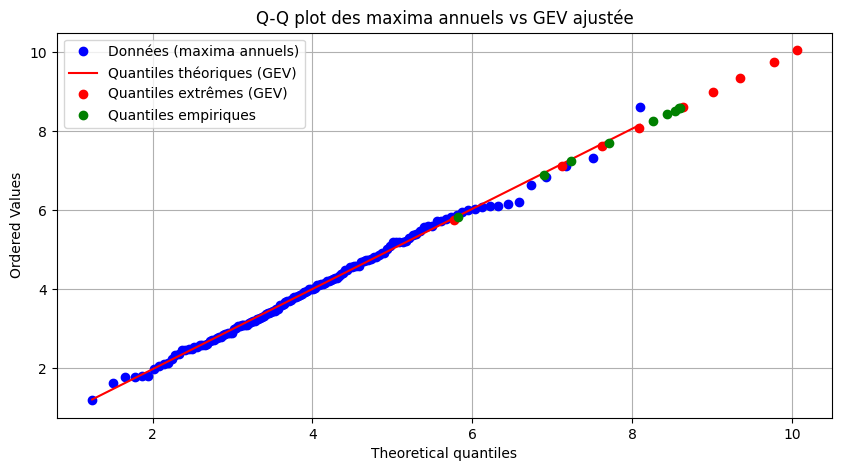

In [24]:
# Affichage du QQ Plot 
plt.figure(figsize=(10, 5))
stats.probplot(
    annual_max,
    dist=stats.genextreme(c, loc=mu, scale=sigma),
    plot=plt
)

# Ajouter un label aux points bleus (données) générés par probplot
ax = plt.gca()
if len(ax.get_lines()) >= 2:
    ax.get_lines()[0].set_label("Données (maxima annuels)")
    ax.get_lines()[1].set_label("Quantiles théoriques (GEV)")

# Points des quantiles extrêmes (rouge) et empiriques (vert) avec labels pour la légende
for i, q in enumerate(quantiles):
    plt.plot(q, q, "ro", label="Quantiles extrêmes (GEV)" if i == 0 else "")

for i, q in enumerate(empirical_quantiles):
    plt.plot(q, q, "go", label="Quantiles empiriques" if i == 0 else "")

plt.title("Q-Q plot des maxima annuels vs GEV ajustée")
plt.legend()
plt.grid()
plt.show()

On remarque que le QQ plot est très linéaire, ce qui suggère que les maxima annuels suivent bien une distribution de Gumbel avec les paramètres estimés.

# Saisonnalité

Étudions l'effet de saisonnalité qui est éventuellement à retirer des données. 

a (niveau moyen) = 1.4554
Amplitude saisonnière = 0.5700 m
Phase = -0.8286 rad


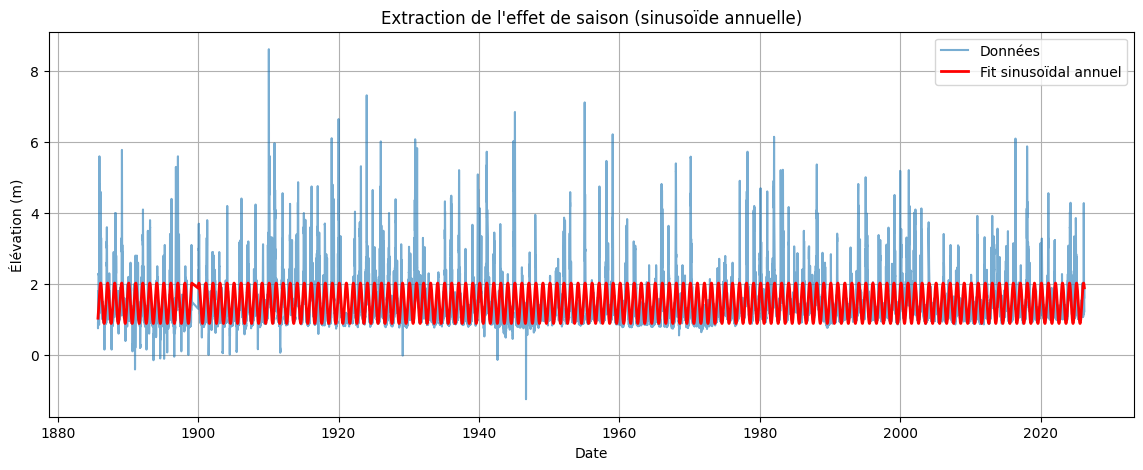

In [18]:
# Fit sinusoïdal (période annuelle) pour capturer la saisonnalité sur l'élévation
t_days = (seine["Date"] - seine["Date"].min()).dt.total_seconds() / 86400.0
y = seine["Hauteur"].values

T = 365.2425  # période annuelle en jours
omega = 2 * np.pi / T

# Modèle: y(t) = a + b*sin(omega*t) + d*cos(omega*t)
X = np.column_stack([
    np.ones_like(t_days),
    np.sin(omega * t_days),
    np.cos(omega * t_days)
])

a, b, d = np.linalg.lstsq(X, y, rcond=None)[0]

# Effet saisonnier estimé (centré) + signal ajusté complet
seasonal_effect = b * np.sin(omega * t_days) + d * np.cos(omega * t_days)
seine["seasonal_effect"] = seasonal_effect
seine["seasonal_fit"] = a + seasonal_effect
seine["elevation_deseasonalized"] = seine["Hauteur"] - seasonal_effect

# Paramètres interprétables
amplitude = np.sqrt(b**2 + d**2)
phase = np.arctan2(d, b)  # pour y = a + A*sin(omega*t + phase)

print(f"a (niveau moyen) = {a:.4f}")
print(f"Amplitude saisonnière = {amplitude:.4f} m")
print(f"Phase = {phase:.4f} rad")

# Visualisation
plt.figure(figsize=(14, 5))
plt.plot(seine["Date"], seine["Hauteur"], label="Données", alpha=0.6)
plt.plot(seine["Date"], seine["seasonal_fit"], color="red", lw=2, label="Fit sinusoïdal annuel")
plt.xlabel("Date")
plt.ylabel("Élévation (m)")
plt.title("Extraction de l'effet de saison (sinusoïde annuelle)")
plt.legend()
plt.grid(True)
plt.show()